# 04 - Graph Attention Networks (GAT)

GCN and SAGE treat every neighbour **equally** (a plain average). But some neighbours
are more informative than others. **GAT** (Velickovic et al., 2018) learns an
**attention weight** $\alpha_{ij}$ for each edge and aggregates a *weighted* average:

$$ h_i' = \sigma\Big( \sum_{j \in N(i)} \alpha_{ij}\, W h_j \Big),
   \qquad \alpha_{ij} = \text{softmax}_j\big(\text{LeakyReLU}(a^\top [Wh_i \Vert Wh_j])\big) $$

Usually with **multiple heads** (several attention patterns in parallel, then combined).
The promise: the model can *down-weight* unhelpful neighbours instead of being dragged
toward them - and the weights are a built-in interpretability signal.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make utils/ importable from notebooks/

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
torch.manual_seed(0); np.random.seed(0)

from utils import graphs as G     # synthetic graph generators (known ground truth)
from utils import models as M     # the model zoo (MLP, GCN, SAGE, GAT, GIN, GPS, ...)
from utils import training as T    # train/eval loops + metrics
from utils import plotting as P    # graph drawing, curves, comparisons


## Train a GAT, then read its attention

We train a 2-head GAT on the homophilous SBM, then extract the learned attention. The
ground-truth question: **does the model put more attention on same-class neighbours**
(the helpful ones) than on cross-class neighbours?

In [2]:
data, gt = G.make_sbm_homophily(homophily=0.8, seed=1)
C = int(data.y.max())+1
T.set_seed(0)
gat = M.GNN(data.num_features, 16, C, conv="gat", n_layers=2, heads=4)
res = T.train_node(gat, data, task="classification", epochs=200)
print(f"GAT test accuracy = {res['test_metric']:.3f}")

# Pull attention from the first layer (edge_index aligned), average over heads.
gat.eval()
with torch.no_grad():
    _, atts = gat(data.x, data.edge_index, return_attention=True)
ei, alpha = atts[0]
a = alpha.mean(1)                                   # [num_edges]
same = data.y[ei[0]] == data.y[ei[1]]
print(f"mean attention on SAME-class edges  = {a[same].mean():.4f}")
print(f"mean attention on CROSS-class edges = {a[~same].mean():.4f}")
print("-> GAT learns to listen more to neighbours that share its label.")

GAT test accuracy = 1.000
mean attention on SAME-class edges  = 0.0891
mean attention on CROSS-class edges = 0.0852
-> GAT learns to listen more to neighbours that share its label.


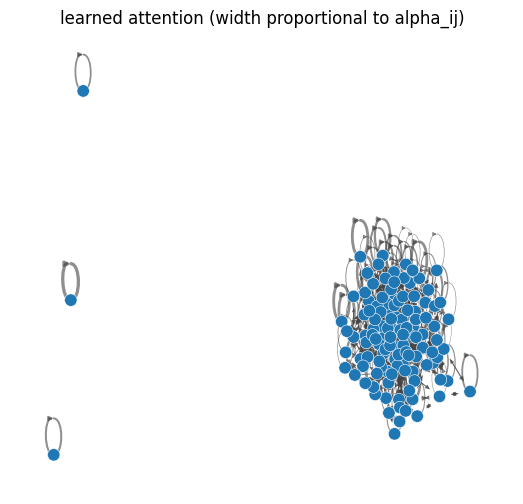

In [3]:
# Visualise: edge opacity/width proportional to attention weight, on a subgraph.
fig, ax = plt.subplots(figsize=(6.5, 6))
P.draw_attention(data, ei, alpha, title="learned attention (width proportional to alpha_ij)", ax=ax, max_nodes=120)
plt.show()

## GAT vs GATv2: static vs *dynamic* attention

The original GAT has a subtle flaw: its scoring is **static** - the *ranking* of
neighbours is the same for every query node (a limitation proven in Brody et al., 2021).
**GATv2** makes attention **dynamic** by reordering the nonlinearity, so different nodes
can prefer different neighbours. It's a drop-in upgrade (`GATv2Conv`).

In [4]:
rows = []
for conv in ["gat", "gatv2"]:
    T.set_seed(0)
    m = M.GNN(data.num_features, 16, C, conv=conv, n_layers=2, heads=4)
    r = T.train_node(m, data, task="classification", epochs=200)
    rows.append({"model": conv.upper(), "test acc": r["test_metric"], "params": r["n_params"]})
pd.DataFrame(rows).round(3)

,model,test acc,params
0,GAT,1.0,2003
1,GATV2,1.0,3795


## When to reach for GAT / GATv2

- (+) When **neighbours vary in usefulness** - noisy graphs, some irrelevant edges, or you
  want the model to *select* which neighbours to trust.
- (+) When you want **edge-level interpretability** (the attention weights).
- (!) More parameters/compute than GCN; on clean homophilous data a plain GCN/SAGE often
  ties it. Prefer **GATv2** over GAT by default (strictly more expressive attention).

Next: **GIN** and the question of how *powerful* a GNN can be - what structures it can
and cannot tell apart.